In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon
from shapely.geometry import Polygon
from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

In [2]:
gdf = gpd.read_parquet('data/blocks_indicator.parquet').to_crs(32636)
gdf.head()

,id,geometry,territory_id,name,Численность населения,Степень урбанизации территории,Средняя доступность до федеральных транспортных магистралей,Средняя доступность до центра региона,Связанность,Связанность населенных пунктов,...,Средняя доступность до центра федерального округа,Социальное обеспечение (базовое),Социальное обеспечение (базовое+),Социальное обеспечение (комфорт),Количество объектов инженерной инфраструктуры,"Количество электростанций (ТЭС, АЭС и пр.)",Количество больших водозаборов,Количество очистительных сооружений,Количество крупных водохранилищ,Количество газораспределительных станций
0,0,"POLYGON ((570883.045 6596529.946, 570883.081 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,"POLYGON ((570987.035 6596464.499, 570987.085 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,"POLYGON ((572676.73 6596606.982, 572676.701 65...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,"POLYGON ((583242.895 6595451.954, 583243.013 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,"POLYGON ((582405.498 6595459.455, 582405.614 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# ML - реальные данные

## Адаптируем статью

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Список типов землепользования
land_use_types = ['residential', 'recreation', 'special', 'industrial', 
                 'agriculture', 'transport', 'business', 'basic',
                 'residential_individual', 'residential_lowrise', 
                 'residential_midrise', 'residential_multistorey', 'mixed_use']

# Влияние типа землепользования на инвестиционную привлекательность
land_use_effect = {
    'residential': 0.7, 'recreation': 0.4, 'special': 0.3, 'industrial': 1.2,
    'agriculture': 0.5, 'transport': 0.8, 'business': 1.6, 'basic': 0.2,
    'residential_individual': 0.9, 'residential_lowrise': 1.0,
    'residential_midrise': 1.1, 'residential_multistorey': 1.3, 'mixed_use': 1.5
}

def calculate_investment_return(gdf, land_use_type, scaler=None):
    if land_use_type not in land_use_types:
        raise ValueError(f"land_use_type должен быть одним из: {land_use_types}")

    df = gdf.drop_duplicates().fillna(0)
    if df.empty:
        raise ValueError("gdf пустой после очистки.")

    df_normalized = df.copy()
    numeric_cols = df_normalized.select_dtypes(include=[np.number]).columns
    non_numeric_cols = [col for col in df_normalized.columns if col not in numeric_cols]
    df_normalized = df_normalized.drop(columns=non_numeric_cols, errors='ignore')

    for col in df_normalized.columns:
        df_normalized[col] = pd.to_numeric(df_normalized[col], errors='coerce').fillna(0)

    id_columns = [col for col in df_normalized.columns if col.lower() in ['id', 'territory_id']]
    numeric_features = [col for col in df_normalized.columns if col not in id_columns and col != 'InvestmentReturn']
    
    if scaler is None:
        scaler = MinMaxScaler()
        df_normalized[numeric_features] = scaler.fit_transform(df_normalized[numeric_features])
    else:
        scaler_features = scaler.feature_names_in_
        common_features = [f for f in numeric_features if f in scaler_features]
        df_normalized[common_features] = scaler.transform(df_normalized[common_features])

    base_investment_return = (
        # Демография и урбанизация (15% = 0.15)
        0.030 * df_normalized['Численность населения'] +
        0.030 * df_normalized['Степень урбанизации территории'] +
        0.030 * df_normalized['Плотность улично-дорожной сети'] +
        0.030 * df_normalized['Связанность населенных пунктов'] +
        0.030 * df_normalized['Обеспеченность общественными пространства'] +
        
        # Транспортная инфраструктура (25% = 0.25)
        0.021 * df_normalized['Протяженность дорог федерального значения'] +
        0.021 * df_normalized['Протяженность дорог регионального значения'] +
        0.021 * df_normalized['Протяженность дорог местного значения'] +
        0.021 * df_normalized['Количество маршрутов общественного транспорта'] +
        0.021 * df_normalized['Количество остановок общественного транспорта'] +
        0.021 * df_normalized['Общая протяженность железнодорожных путей'] +
        0.021 * df_normalized['Количество остановок железнодорожного транспорта'] +
        0.021 * (1 - df_normalized['Средняя доступность до федеральных транспортных магистралей']) +
        0.021 * (1 - df_normalized['Средняя доступность остановок железнодорожного транспорта']) +
        0.021 * df_normalized['Количество международных аэропортов'] +
        0.021 * df_normalized['Количество аэропортов местного значения'] +
        0.021 * df_normalized['Количество портов'] +
        
        # Социальная инфраструктура (25% = 0.25)
        0.018 * df_normalized['Обеспеченность детскими садами'] +
        0.018 * df_normalized['Обеспеченность школами'] +
        0.018 * df_normalized['Обеспеченность центрами детского творчества'] +
        0.018 * df_normalized['Обеспеченность школами искусств'] +
        0.018 * df_normalized['Обеспеченность ФАП / амбулаториями'] +
        0.018 * df_normalized['Обеспеченность аптеками'] +
        0.018 * df_normalized['Обеспеченность поликлиниками / центрами семейной медицины'] +
        0.018 * df_normalized['Обеспеченность участковыми больницами'] +
        0.018 * df_normalized['Обеспеченность городскими больницами (д/в)'] +
        0.018 * df_normalized['Обеспеченность детскими площадками'] +
        0.017 * df_normalized['Обеспеченность скверами / бульварами / лесопарками'] +
        0.017 * df_normalized['Обеспеченность парками'] +
        0.017 * df_normalized['Обеспеченность парками развлечений'] +
        0.017 * df_normalized['Социальное обеспечение (комфорт)'] +
        
        # Экономические факторы (20% = 0.20)
        0.020 * df_normalized['Обеспеченность продуктовыми магазинами'] +
        0.020 * df_normalized['Обеспеченность хозяйственными магазинами'] +
        0.020 * df_normalized['Обеспеченность ТЦ / супермаркетами'] +
        0.020 * df_normalized['Обеспеченность ТРК / гипермаркетами'] +
        0.020 * df_normalized['Обеспеченность профильными магазинами'] +
        0.020 * df_normalized['Обеспеченность кафе / кофейнями'] +
        0.020 * df_normalized['Обеспеченность барами / ресторанами'] +
        0.020 * df_normalized['Обеспеченность коммерческими клиниками'] +
        0.020 * df_normalized['Обеспеченность отделениями банков'] +
        0.020 * df_normalized['Количество автозаправочных станций'] +
        
        # Связанность и доступность (15% = 0.15)
        0.021 * df_normalized['Связанность'] +
        0.021 * (1 - df_normalized['Средняя доступность до центра региона']) +
        0.021 * (1 - df_normalized['Средняя доступность до федерального центра']) +
        0.021 * (1 - df_normalized['Средняя доступность до центра федерального округа']) +
        0.021 * df_normalized['Связанность общественным транспортом'] +
        0.021 * df_normalized['Количество объектов инженерной инфраструктуры'] +
        0.021 * df_normalized['Количество электростанций (ТЭС, АЭС и пр.)']
    )
    land_use_factor = land_use_effect[land_use_type]
    df['InvestmentReturn'] = base_investment_return * land_use_factor
    max_possible_value = 1.0 * max(land_use_effect.values())
    df['InvestmentReturn'] = df['InvestmentReturn'] / max_possible_value

    df['LandUseType'] = land_use_type
    return df

def prepare_for_training(gdf):
    if 'InvestmentReturn' not in gdf.columns:
        raise ValueError("В gdf отсутствует столбец InvestmentReturn.")
    if 'LandUseType' not in gdf.columns:
        raise ValueError("В gdf отсутствует столбец LandUseType.")

    df = gdf.copy()
    df = pd.get_dummies(df, columns=['LandUseType'], prefix='LandUse')
    id_columns = [col for col in df.columns if col.lower() in ['id', 'territory_id']]
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    non_numeric_cols = [col for col in df.columns if col not in numeric_cols and col not in id_columns and not col.startswith('LandUse')]
    df = df.drop(columns=non_numeric_cols, errors='ignore')
    df = df.drop(columns=['geometry'], errors='ignore')

    for col in df.columns:
        if col != 'InvestmentReturn':
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    scaler = MinMaxScaler()
    numeric_features = [col for col in df.columns if col not in id_columns and not col.startswith('LandUse') and col != 'InvestmentReturn']
    df[numeric_features] = scaler.fit_transform(df[numeric_features])

    for col in df.columns:
        if col.startswith('LandUse_'):
            df[col] = df[col].astype(int)

    df['Stratum'] = pd.qcut(df['InvestmentReturn'], q=4, labels=False, duplicates='drop')
    X = df.drop(['InvestmentReturn', 'Stratum'], axis=1)
    y = df['InvestmentReturn']

    X_train, X_test, y_train, y_test = train_test_split(
        X.values, y.values,
        train_size=0.75,
        stratify=df['Stratum'],
        random_state=42
    )

    X_columns = X.columns.tolist()
    dtypes = {col: 'float64' if col not in id_columns and not col.startswith('LandUse_') else 'int64' for col in X_columns}
    return X_train, X_test, y_train, y_test, scaler, X_columns, dtypes

def evaluate_model(model, X_train, X_test, y_train, y_test):
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    mape_train = mean_absolute_percentage_error(y_train, y_train_pred)
    mape_test = mean_absolute_percentage_error(y_test, y_test_pred)
    nrmse_train = np.sqrt(np.mean((y_train - y_train_pred) ** 2)) / (y_train.max() - y_train.min())
    nrmse_test = np.sqrt(np.mean((y_test - y_test_pred) ** 2)) / (y_test.max() - y_test.min())
    
    print("\nTraining Performance:")
    print(f"R²: {r2_train:.3f}")
    print(f"MAPE: {mape_train:.3f}")
    print(f"nRMSE: {nrmse_train:.3f}")
    
    print("\nTest Performance:")
    print(f"R²: {r2_test:.3f}")
    print(f"MAPE: {mape_test:.3f}")
    print(f"nRMSE: {nrmse_test:.3f}")
    
    return {
        'r2_train': r2_train, 'r2_test': r2_test,
        'mape_train': mape_train, 'mape_test': mape_test,
        'nrmse_train': nrmse_train, 'nrmse_test': nrmse_test
    }

/Users/mvin/Code/Urbanomy/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [10]:
df_with_returns = calculate_investment_return(gdf, 'residential')  # gdf - ваш исходный GeoDataFrame
df_with_returns

,id,geometry,territory_id,name,Численность населения,Степень урбанизации территории,Средняя доступность до федеральных транспортных магистралей,Средняя доступность до центра региона,Связанность,Связанность населенных пунктов,...,Социальное обеспечение (базовое+),Социальное обеспечение (комфорт),Количество объектов инженерной инфраструктуры,"Количество электростанций (ТЭС, АЭС и пр.)",Количество больших водозаборов,Количество очистительных сооружений,Количество крупных водохранилищ,Количество газораспределительных станций,InvestmentReturn,LandUseType
0,0,"POLYGON ((570883.045 6596529.946, 570883.081 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.106077,residential
1,1,"POLYGON ((570987.035 6596464.499, 570987.085 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.106077,residential
2,2,"POLYGON ((572676.73 6596606.982, 572676.701 65...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.106077,residential
3,3,"POLYGON ((583242.895 6595451.954, 583243.013 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.106077,residential
4,4,"POLYGON ((582405.498 6595459.455, 582405.614 6...",3.0,Самойловское сельское поселение,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.106077,residential
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34642,34645,"POLYGON ((279466.739 6647657.982, 279466.837 6...",1267.0,город Сосновый бор,63462.0,66.50,0.000,0.000000,0.000000,0.00,...,0.0,0.0,6.0,0.0,0.0,5.0,1.0,0.0,0.072004,residential
34643,34646,"POLYGON ((279467.148 6647660.126, 279467.165 6...",1267.0,город Сосновый бор,63462.0,66.50,0.000,0.000000,0.000000,0.00,...,0.0,0.0,6.0,0.0,0.0,5.0,1.0,0.0,0.072004,residential
34644,34647,"POLYGON ((279542.296 6648001.072, 279542.336 6...",1267.0,город Сосновый бор,63462.0,66.50,0.000,0.000000,0.000000,0.00,...,0.0,0.0,6.0,0.0,0.0,5.0,1.0,0.0,0.072004,residential
34645,34648,"POLYGON ((279625.847 6648207.164, 279625.886 6...",1267.0,город Сосновый бор,63462.0,66.50,0.000,0.000000,0.000000,0.00,...,0.0,0.0,6.0,0.0,0.0,5.0,1.0,0.0,0.072004,residential


Using all 82 features: ['id', 'territory_id', 'Численность населения', 'Степень урбанизации территории', 'Средняя доступность до федеральных транспортных магистралей', 'Средняя доступность до центра региона', 'Связанность', 'Связанность населенных пунктов', 'Плотность улично-дорожной сети', 'Протяженность дорог федерального значения', 'Протяженность дорог регионального значения', 'Протяженность дорог местного значения', 'Количество маршрутов общественного транспорта', 'Количество остановок общественного транспорта', 'Количество автозаправочных станций', 'Средняя доступность  автозаправочных станций', 'Общая протяженность железнодорожных путей', 'Количество остановок железнодорожного транспорта', 'Средняя доступность остановок железнодорожного транспорта', 'Количество международных аэропортов', 'Количество аэропортов местного значения', 'Средняя доступность международных аэропортов', 'Средняя доступность аэропортов местного значения', 'Количество портов', 'Обеспеченность детскими садами

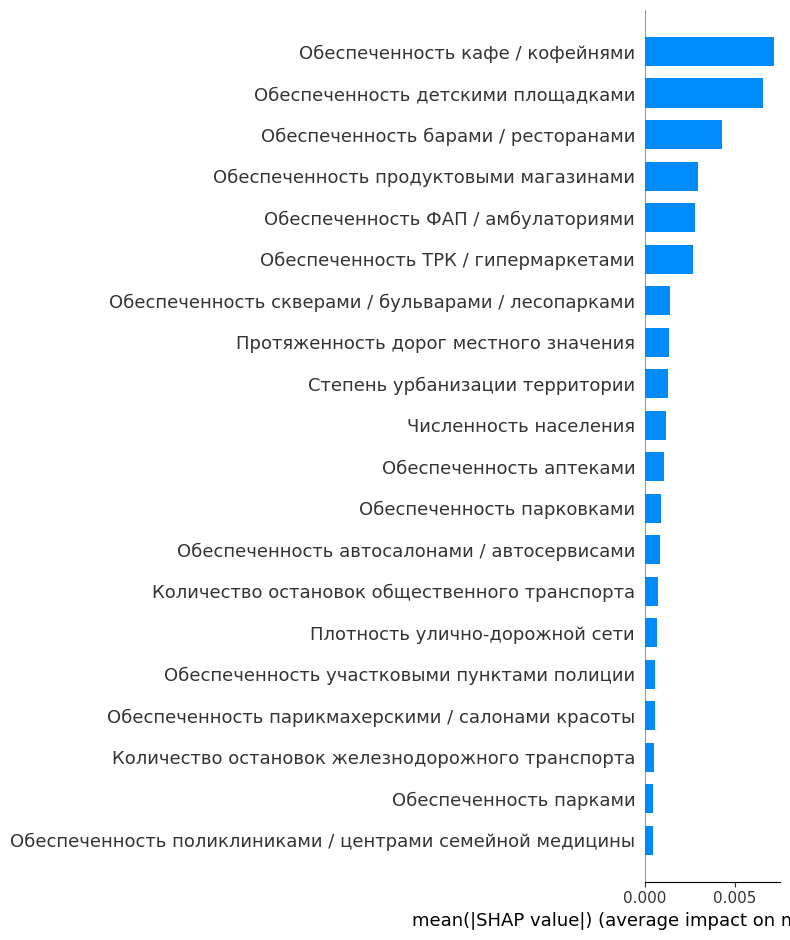


Generating SHAP Summary Plot (dot)...


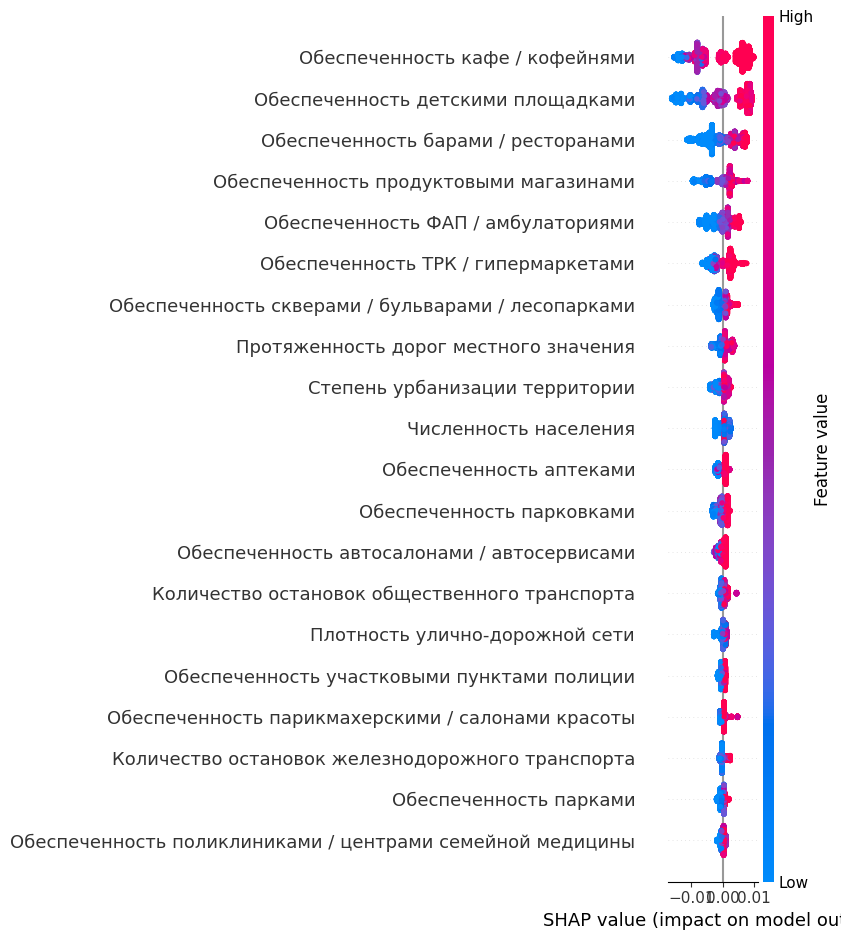


Generating SHAP Dependence Plot for Обеспеченность кафе / кофейнями...


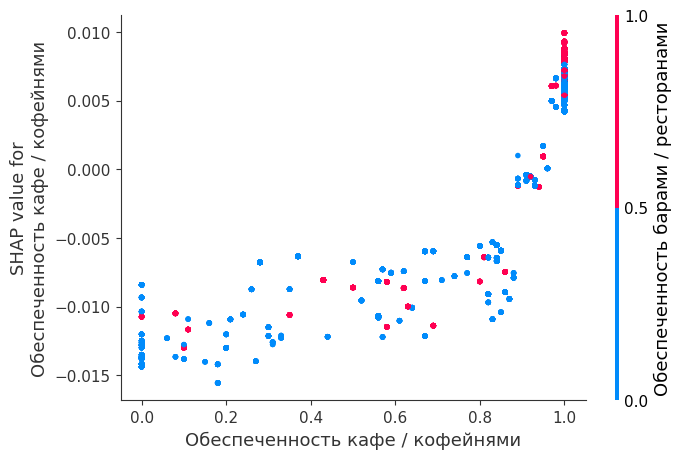


Generating SHAP Dependence Plot for Обеспеченность детскими площадками...


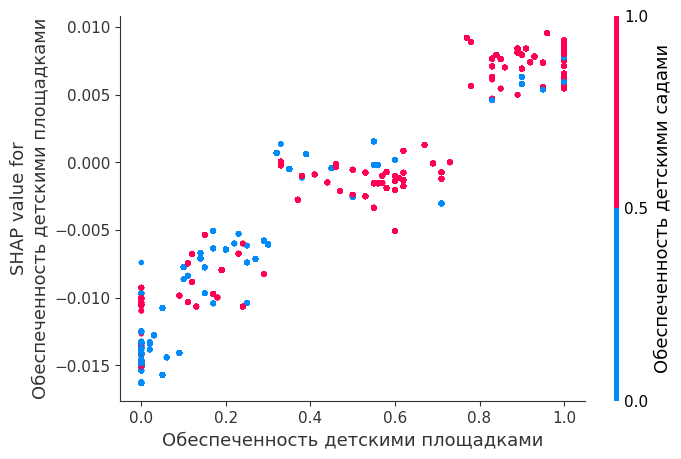


Generating SHAP Dependence Plot for Численность населения...


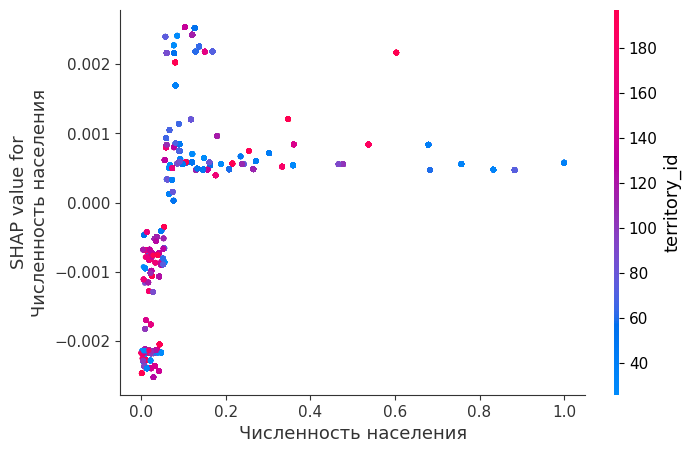


Baseline Model Performance:

Training Performance:
R²: 0.999
MAPE: 0.002
nRMSE: 0.004

Test Performance:
R²: 0.999
MAPE: 0.002
nRMSE: 0.004

Predicted InvestmentReturn for gdf_new: 0.163

Generating SHAP Waterfall Plot for gdf_new...


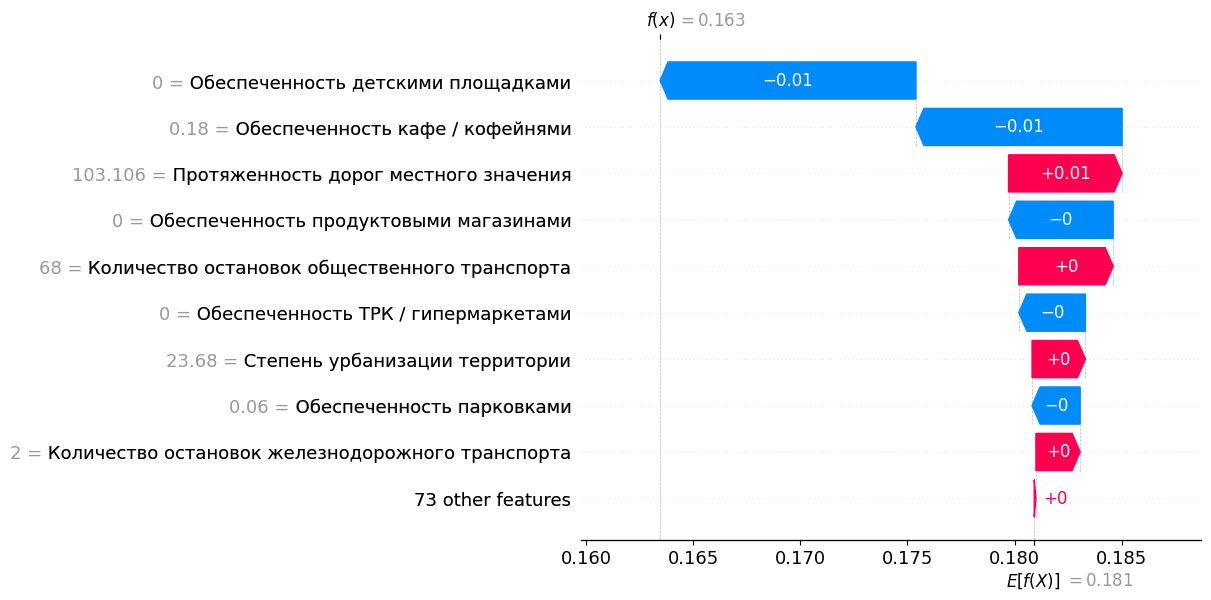

In [5]:
# Основной код обучения
df_with_returns = calculate_investment_return(gdf, 'transport')  # gdf - ваш исходный GeoDataFrame
X_train, X_test, y_train, y_test, scaler, X_columns, dtypes = prepare_for_training(df_with_returns)

# Преобразуем X_train и X_test обратно в DataFrame с правильными типами
X_train_df = pd.DataFrame(X_train, columns=X_columns).astype(dtypes)
X_test_df = pd.DataFrame(X_test, columns=X_columns).astype(dtypes)

# Очистка целевой переменной
y_train = pd.Series(y_train).replace([np.inf, -np.inf], np.nan).dropna()
y_test = pd.Series(y_test).replace([np.inf, -np.inf], np.nan).dropna()
y_train = y_train.clip(lower=0, upper=1)
y_test = y_test.clip(lower=0, upper=1)

# Синхронизация индексов
X_train_df = X_train_df.loc[y_train.index]
X_test_df = X_test_df.loc[y_test.index]

# Используем все признаки
print(f"Using all {len(X_columns)} features: {X_columns}")

# Обучение модели с лучшими параметрами
best_params = {
    'alpha': 10.0,
    'colsample_bytree': 0.8,
    'learning_rate': 0.1,
    'max_depth': 4,
    'n_estimators': 300,
    'subsample': 1.0,
    'random_state': 42
}

best_model = XGBRegressor(**best_params)
best_model.fit(X_train_df, y_train)
print("Model trained with parameters:", best_params)

# Оценка модели
metrics = evaluate_model(best_model, X_train_df, X_test_df, y_train, y_test)

# Важность признаков (встроенная в XGBoost)
feature_importance = pd.DataFrame({
    'Feature': X_columns,
    'Importance': best_model.feature_importances_
})
feature_importance = feature_importance.sort_values('Importance', ascending=False)
print("\nFeature Importance (XGBoost):")
print(feature_importance)

# SHAP-анализ
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_df)

# 1. Summary Plot (общая важность признаков)
print("\nGenerating SHAP Summary Plot...")
shap.summary_plot(shap_values, X_test_df, plot_type="bar")
plt.show()

# 2. Summary Plot (распределение влияния признаков)
print("\nGenerating SHAP Summary Plot (dot)...")
shap.summary_plot(shap_values, X_test_df)
plt.show()

# 3. Dependence Plot для топ-3 признаков
top_features = feature_importance['Feature'].head(3).tolist()
for feature in top_features:
    print(f"\nGenerating SHAP Dependence Plot for {feature}...")
    shap.dependence_plot(feature, shap_values, X_test_df)
    plt.show()

# Сравнение с базовой моделью
base_model = XGBRegressor(n_estimators=500, max_depth=6, learning_rate=0.3, alpha=1.0, random_state=42)
base_model.fit(X_train_df, y_train)
print("\nBaseline Model Performance:")
base_metrics = evaluate_model(base_model, X_train_df, X_test_df, y_train, y_test)

# Пример предсказания для gdf_new
gdf_new = gdf.iloc[[0]]
result = calculate_investment_return(gdf_new, 'residential', scaler)
X_new = pd.get_dummies(result.drop(columns=['InvestmentReturn', 'geometry'], errors='ignore'), columns=['LandUseType'], prefix='LandUse')
X_new = X_new.drop(columns=[col for col in X_new.columns if col.lower() in ['id', 'territory_id'] or col not in X_columns], errors='ignore')
for col in X_columns:
    if col not in X_new.columns:
        X_new[col] = 0
X_new = X_new[X_columns].astype(dtypes)
prediction = best_model.predict(X_new)
print(f"\nPredicted InvestmentReturn for gdf_new: {prediction[0]:.3f}")

# SHAP-анализ для gdf_new
shap_values_new = explainer.shap_values(X_new)
print("\nGenerating SHAP Waterfall Plot for gdf_new...")
shap.waterfall_plot(shap.Explanation(values=shap_values_new[0], 
                                     base_values=explainer.expected_value, 
                                     data=X_new.iloc[0], 
                                     feature_names=X_new.columns.tolist()))
plt.show()

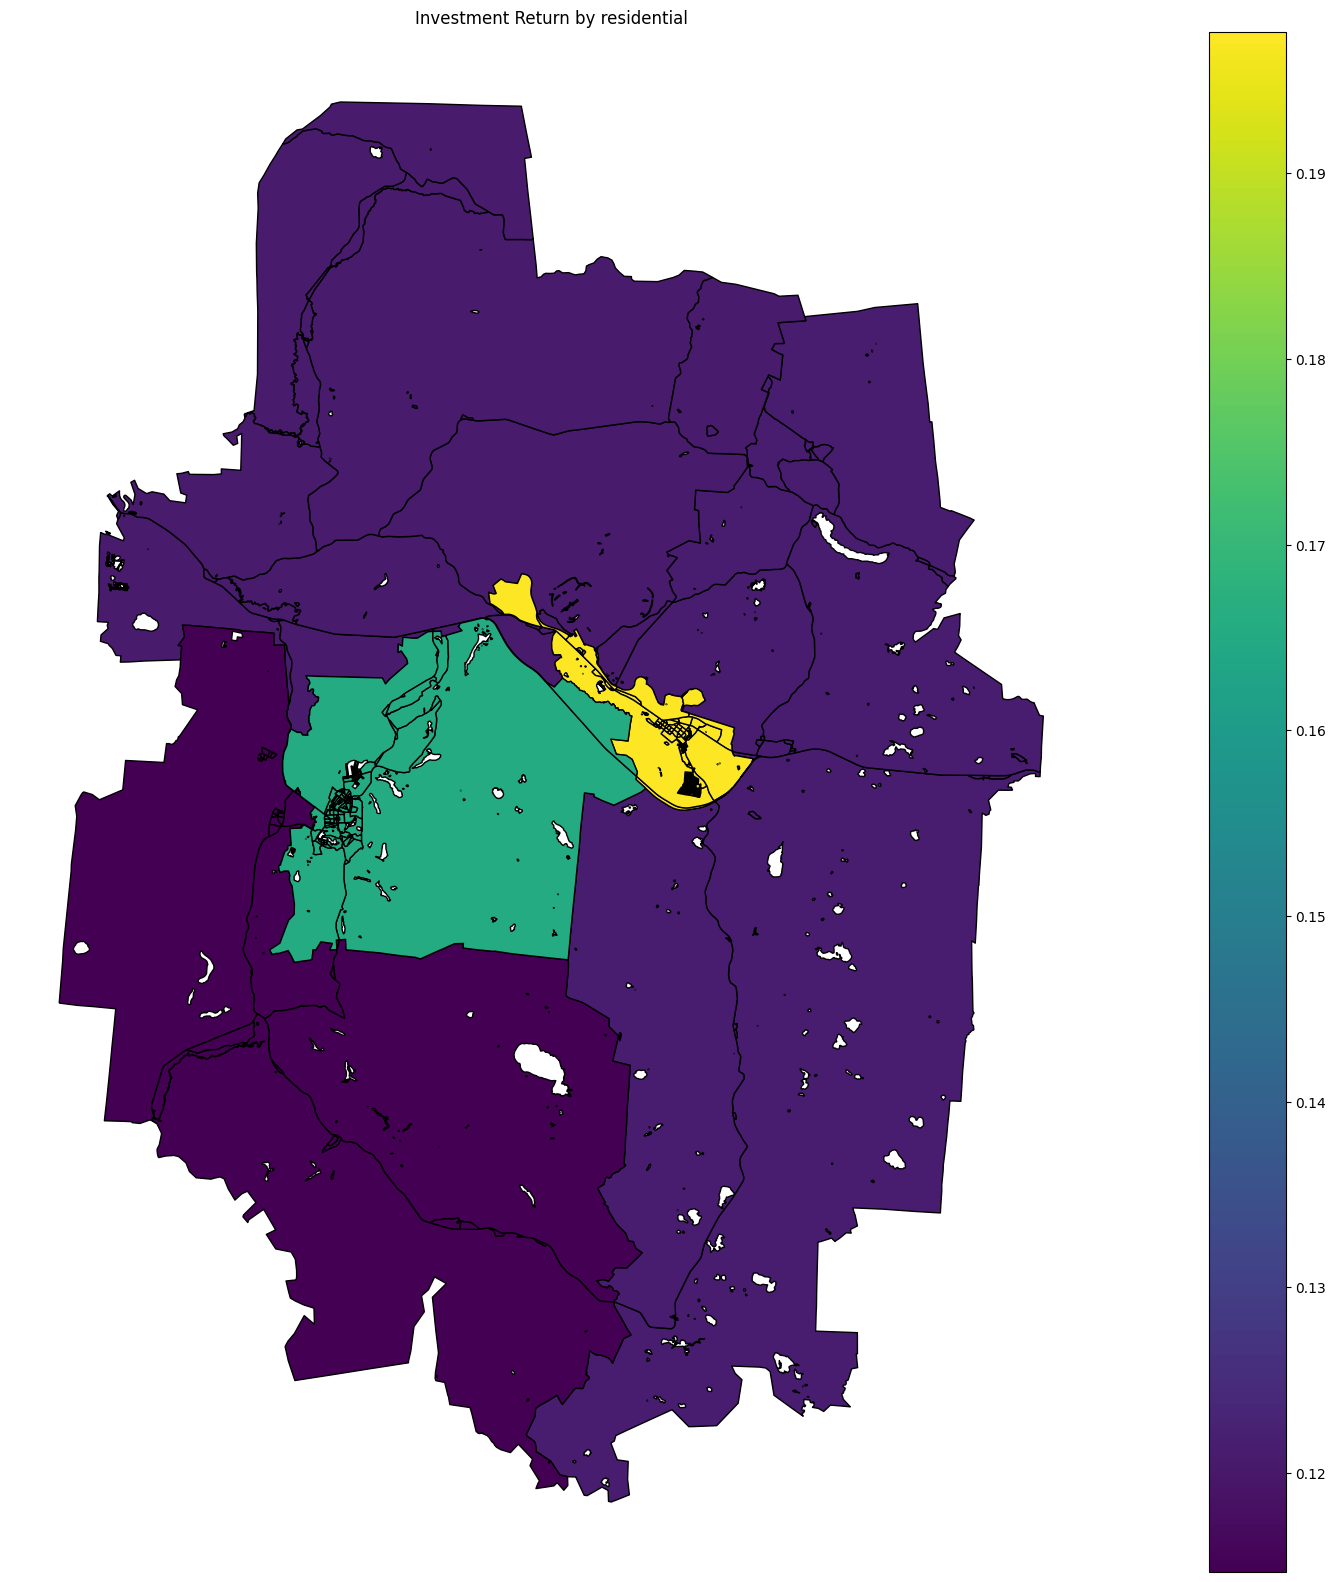

In [6]:

df_with_returns.head(500).plot(column='InvestmentReturn',
         cmap='viridis',           # или 'OrRd', 'coolwarm', 'plasma', см. ниже для других вариантов
         legend=True,
         edgecolor='black',
         figsize=(30, 20))
plt.title('Investment Return by residential')  # или другая подходящая подпись
plt.axis('off')
plt.show()

# Тест

In [24]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_percentage_error
import shap
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Константы
land_use_types = ['residential', 'recreation', 'special', 'industrial', 
                 'agriculture', 'transport', 'business', 'basic',
                 'residential_individual', 'residential_lowrise', 
                 'residential_midrise', 'residential_multistorey', 'mixed_use']

land_use_effect = {
    'residential': 0.7, 'recreation': 0.4, 'special': 0.3, 'industrial': 1.2,
    'agriculture': 0.5, 'transport': 0.8, 'business': 1.6, 'basic': 0.2,
    'residential_individual': 0.9, 'residential_lowrise': 1.0,
    'residential_midrise': 1.1, 'residential_multistorey': 1.3, 'mixed_use': 1.5
}

# Вспомогательная функция для нормализации и расчета базового значения
def _calculate_base_return(df, scaler=None):
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df_numeric = df[numeric_cols]
    
    if scaler is None:
        scaler = MinMaxScaler()
        df_normalized = pd.DataFrame(scaler.fit_transform(df_numeric), 
                                   columns=df_numeric.columns, 
                                   index=df_numeric.index)
    else:
        df_normalized = pd.DataFrame(scaler.transform(df_numeric), 
                                   columns=df_numeric.columns, 
                                   index=df_numeric.index)
    
    base_return = (
        # Демография и урбанизация (15% = 0.15)
        0.030 * df_normalized['Численность населения'] +
        0.030 * df_normalized['Степень урбанизации территории'] +
        0.030 * df_normalized['Плотность улично-дорожной сети'] +
        0.030 * df_normalized['Связанность населенных пунктов'] +
        0.030 * df_normalized['Обеспеченность общественными пространства'] +
        
        # Транспортная инфраструктура (25% = 0.25)
        0.021 * df_normalized['Протяженность дорог федерального значения'] +
        0.021 * df_normalized['Протяженность дорог регионального значения'] +
        0.021 * df_normalized['Протяженность дорог местного значения'] +
        0.021 * df_normalized['Количество маршрутов общественного транспорта'] +
        0.021 * df_normalized['Количество остановок общественного транспорта'] +
        0.021 * df_normalized['Общая протяженность железнодорожных путей'] +
        0.021 * df_normalized['Количество остановок железнодорожного транспорта'] +
        0.021 * (1 - df_normalized['Средняя доступность до федеральных транспортных магистралей']) +
        0.021 * (1 - df_normalized['Средняя доступность остановок железнодорожного транспорта']) +
        0.021 * df_normalized['Количество международных аэропортов'] +
        0.021 * df_normalized['Количество аэропортов местного значения'] +
        0.021 * df_normalized['Количество портов'] +
        
        # Социальная инфраструктура (25% = 0.25)
        0.018 * df_normalized['Обеспеченность детскими садами'] +
        0.018 * df_normalized['Обеспеченность школами'] +
        0.018 * df_normalized['Обеспеченность центрами детского творчества'] +
        0.018 * df_normalized['Обеспеченность школами искусств'] +
        0.018 * df_normalized['Обеспеченность ФАП / амбулаториями'] +
        0.018 * df_normalized['Обеспеченность аптеками'] +
        0.018 * df_normalized['Обеспеченность поликлиниками / центрами семейной медицины'] +
        0.018 * df_normalized['Обеспеченность участковыми больницами'] +
        0.018 * df_normalized['Обеспеченность городскими больницами (д/в)'] +
        0.018 * df_normalized['Обеспеченность детскими площадками'] +
        0.017 * df_normalized['Обеспеченность скверами / бульварами / лесопарками'] +
        0.017 * df_normalized['Обеспеченность парками'] +
        0.017 * df_normalized['Обеспеченность парками развлечений'] +
        0.017 * df_normalized['Социальное обеспечение (комфорт)'] +
        
        # Экономические факторы (20% = 0.20)
        0.020 * df_normalized['Обеспеченность продуктовыми магазинами'] +
        0.020 * df_normalized['Обеспеченность хозяйственными магазинами'] +
        0.020 * df_normalized['Обеспеченность ТЦ / супермаркетами'] +
        0.020 * df_normalized['Обеспеченность ТРК / гипермаркетами'] +
        0.020 * df_normalized['Обеспеченность профильными магазинами'] +
        0.020 * df_normalized['Обеспеченность кафе / кофейнями'] +
        0.020 * df_normalized['Обеспеченность барами / ресторанами'] +
        0.020 * df_normalized['Обеспеченность коммерческими клиниками'] +
        0.020 * df_normalized['Обеспеченность отделениями банков'] +
        0.020 * df_normalized['Количество автозаправочных станций'] +
        
        # Связанность и доступность (15% = 0.15)
        0.021 * df_normalized['Связанность'] +
        0.021 * (1 - df_normalized['Средняя доступность до центра региона']) +
        0.021 * (1 - df_normalized['Средняя доступность до федерального центра']) +
        0.021 * (1 - df_normalized['Средняя доступность до центра федерального округа']) +
        0.021 * df_normalized['Связанность общественным транспортом'] +
        0.021 * df_normalized['Количество объектов инженерной инфраструктуры'] +
        0.021 * df_normalized['Количество электростанций (ТЭС, АЭС и пр.)']
    )
    
    return base_return, scaler

# 1. Отдельная функция для вычисления инвестиционной привлекательности
def calculate_investment_attractiveness(gdf, land_use_type, scaler=None):
    if land_use_type not in land_use_types:
        raise ValueError(f"land_use_type должен быть одним из: {land_use_types}")
    
    df = gdf.drop_duplicates().fillna(0)
    if df.empty:
        raise ValueError("gdf пустой после очистки.")
    
    # Рассчитываем базовое значение и получаем scaler
    base_return, scaler = _calculate_base_return(df, scaler)
    
    # Применяем коэффициент для типа землепользования
    land_use_factor = land_use_effect[land_use_type]
    max_possible_value = 1.0 * max(land_use_effect.values())
    df['InvestmentReturn'] = (base_return * land_use_factor) / max_possible_value
    df['LandUseType'] = land_use_type
    
    return df, scaler

# 2. Оптимизированная функция создания обучающего набора данных
def create_training_dataframe(gdf, features):
    # Подготовка данных один раз
    df = gdf.drop_duplicates().fillna(0)
    
    # Рассчитываем базовое значение один раз
    base_return, scaler = _calculate_base_return(df)
    max_possible_value = 1.0 * max(land_use_effect.values())
    
    # Создание обучающего набора
    training_data = []
    for idx in df.index:
        for land_type in land_use_types:
            sample = {'LandUseType': land_type}
            for feature_name, feature_series in features.items():
                sample[feature_name] = feature_series.iloc[idx]
            
            # Рассчитываем InvestmentReturn
            land_use_factor = land_use_effect[land_type]
            sample['InvestmentReturn'] = (base_return.iloc[idx] * land_use_factor) / max_possible_value
            
            training_data.append(sample)
    
    # Создаем итоговый DataFrame
    training_df = pd.DataFrame(training_data)
    
    # Обработка числовых столбцов
    for col in training_df.columns:
        if col != 'LandUseType':
            training_df[col] = pd.to_numeric(training_df[col], errors='coerce')
            training_df[col] = training_df[col].replace([np.inf, -np.inf], np.nan)
            training_df[col] = training_df[col].fillna(training_df[col].median())
            training_df[col] = training_df[col].clip(lower=0, upper=1e6)
    
    return training_df
# 3. Функция подготовки данных для модели
def prepare_model_data(df):
    # Создаем копию DataFrame с one-hot encoding для LandUseType
    df_encoded = pd.get_dummies(df, columns=['LandUseType'], prefix='LandUse')
    
    # Определяем столбцы ID для исключения (в любом регистре)
    id_columns = [col for col in df_encoded.columns if col.lower() in ['id', 'territory_id']]
    
    # Исключаем InvestmentReturn и ID-столбцы из признаков
    X = df_encoded.drop(columns=['InvestmentReturn'] + id_columns, axis=1)
    y = df_encoded['InvestmentReturn']
    
    # Нормализация признаков
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Разделение на обучающую и тестовую выборки
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, train_size=0.75, random_state=42
    )
    
    return X_train, X_test, y_train, y_test, scaler, X.columns

# 4. Функция обучения модели
def train_model(X_train, y_train):
    model = XGBRegressor(
        n_estimators=300, max_depth=4, learning_rate=0.1,
        alpha=10.0, colsample_bytree=0.8, subsample=1.0, random_state=42
    )
    model.fit(X_train, y_train)
    return model

# 5. Функция предсказания для одной территории
def predict_investment_attractiveness(gdf, model, scaler, feature_columns):
    df = gdf.drop(columns=['geometry'], errors='ignore')
    
    results = []
    for land_type in land_use_types:
        sample = pd.DataFrame(columns=feature_columns)
        for col in feature_columns:
            if col.startswith('LandUse_'):
                sample[col] = [1 if col == f'LandUse_{land_type}' else 0]
            elif col in df.columns:
                sample[col] = df[col].iloc[0]
            else:
                sample[col] = 0
        
        X_scaled = scaler.transform(sample)
        prediction = model.predict(X_scaled)[0]
        results.append({
            'LandUseType': land_type,
            'InvestmentReturn': prediction
        })
    
    return pd.DataFrame(results)

def get_model_statistics(model, X_train, X_test, y_train, y_test, feature_columns, gdf=None, scaler=None):
    # Базовые метрики
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    stats = {
        'r2_train': r2_score(y_train, y_train_pred),
        'r2_test': r2_score(y_test, y_test_pred),
        'mape_train': mean_absolute_percentage_error(y_train, y_train_pred),
        'mape_test': mean_absolute_percentage_error(y_test, y_test_pred),
        'nrmse_train': np.sqrt(np.mean((y_train - y_train_pred) ** 2)) / (y_train.max() - y_train.min()),
        'nrmse_test': np.sqrt(np.mean((y_test - y_test_pred) ** 2)) / (y_test.max() - y_test.min())
    }
    
    # Преобразуем X_test в DataFrame для SHAP
    X_test_df = pd.DataFrame(X_test, columns=feature_columns)
    
    # SHAP-анализ
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test_df)
    
    # 1. Summary Plot (общая важность признаков)
    print("\nGenerating SHAP Summary Plot (bar)...")
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_df, plot_type="bar")
    plt.title("SHAP Summary Plot (Bar)")
    plt.show()
    
    # 2. Summary Plot (распределение влияния признаков)
    print("\nGenerating SHAP Summary Plot (dot)...")
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_df)
    plt.title("SHAP Summary Plot (Dot)")
    plt.show()
    
    # Важность признаков для выбора топ-3
    feature_importance = pd.DataFrame({
        'Feature': feature_columns,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    # 3. Dependence Plot для топ-3 признаков
    top_features = feature_importance['Feature'].head(3).tolist()
    for feature in top_features:
        print(f"\nGenerating SHAP Dependence Plot for {feature}...")
        plt.figure(figsize=(10, 6))
        shap.dependence_plot(feature, shap_values, X_test_df)
        plt.title(f"SHAP Dependence Plot for {feature}")
        plt.show()
    
    # Сравнение с базовой моделью
    base_model = XGBRegressor(
        n_estimators=500, max_depth=6, learning_rate=0.3, 
        alpha=1.0, random_state=42
    )
    base_model.fit(X_train, y_train)
    print("\nBaseline Model Performance:")
    base_y_train_pred = base_model.predict(X_train)
    base_y_test_pred = base_model.predict(X_test)
    base_stats = {
        'r2_train': r2_score(y_train, base_y_train_pred),
        'r2_test': r2_score(y_test, base_y_test_pred),
        'mape_train': mean_absolute_percentage_error(y_train, base_y_train_pred),
        'mape_test': mean_absolute_percentage_error(y_test, base_y_test_pred),
        'nrmse_train': np.sqrt(np.mean((y_train - base_y_train_pred) ** 2)) / (y_train.max() - y_train.min()),
        'nrmse_test': np.sqrt(np.mean((y_test - y_test_pred) ** 2)) / (y_test.max() - y_test.min())
    }
    for metric, value in base_stats.items():
        print(f"{metric}: {value:.3f}")
    
    # Пример предсказания и SHAP для новой территории (если передан gdf)
    if gdf is not None and scaler is not None:
        gdf_new = gdf.iloc[[0]]
        result, _ = calculate_investment_attractiveness(gdf_new, 'residential', scaler)
        
        # Удаляем ненужные столбцы и добавляем one-hot encoding
        id_columns = [col for col in result.columns if col.lower() in ['id', 'territory_id']]
        X_new = result.drop(columns=['InvestmentReturn', 'geometry'] + id_columns, errors='ignore')
        X_new = pd.get_dummies(X_new, columns=['LandUseType'], prefix='LandUse')
        
        # Приводим к тому же набору столбцов, что в feature_columns
        for col in feature_columns:
            if col not in X_new.columns:
                X_new[col] = 0
        X_new = X_new[feature_columns]  # Оставляем только нужные столбцы в правильном порядке
        
        # Преобразуем с помощью scaler
        X_new_scaled = scaler.transform(X_new)
        
        # Предсказание
        prediction = model.predict(X_new_scaled)
        print(f"\nPredicted InvestmentReturn for gdf_new: {prediction[0]:.3f}")
        
        # SHAP-анализ для gdf_new
        shap_values_new = explainer.shap_values(X_new)
        print("\nGenerating SHAP Waterfall Plot for gdf_new...")
        plt.figure(figsize=(10, 6))
        shap.waterfall_plot(shap.Explanation(
            values=shap_values_new[0],
            base_values=explainer.expected_value,
            data=X_new.iloc[0],
            feature_names=X_new.columns.tolist()
        ))
        plt.title("SHAP Waterfall Plot for New Prediction")
        plt.show()
    
    return stats, base_stats, feature_importance


In [22]:
base_df, base_scaler = calculate_investment_attractiveness(gdf, 'residential')
print("Базовая привлекательность:\n", base_df[['InvestmentReturn', 'LandUseType']].head())

NameError: name 'gdf' is not defined

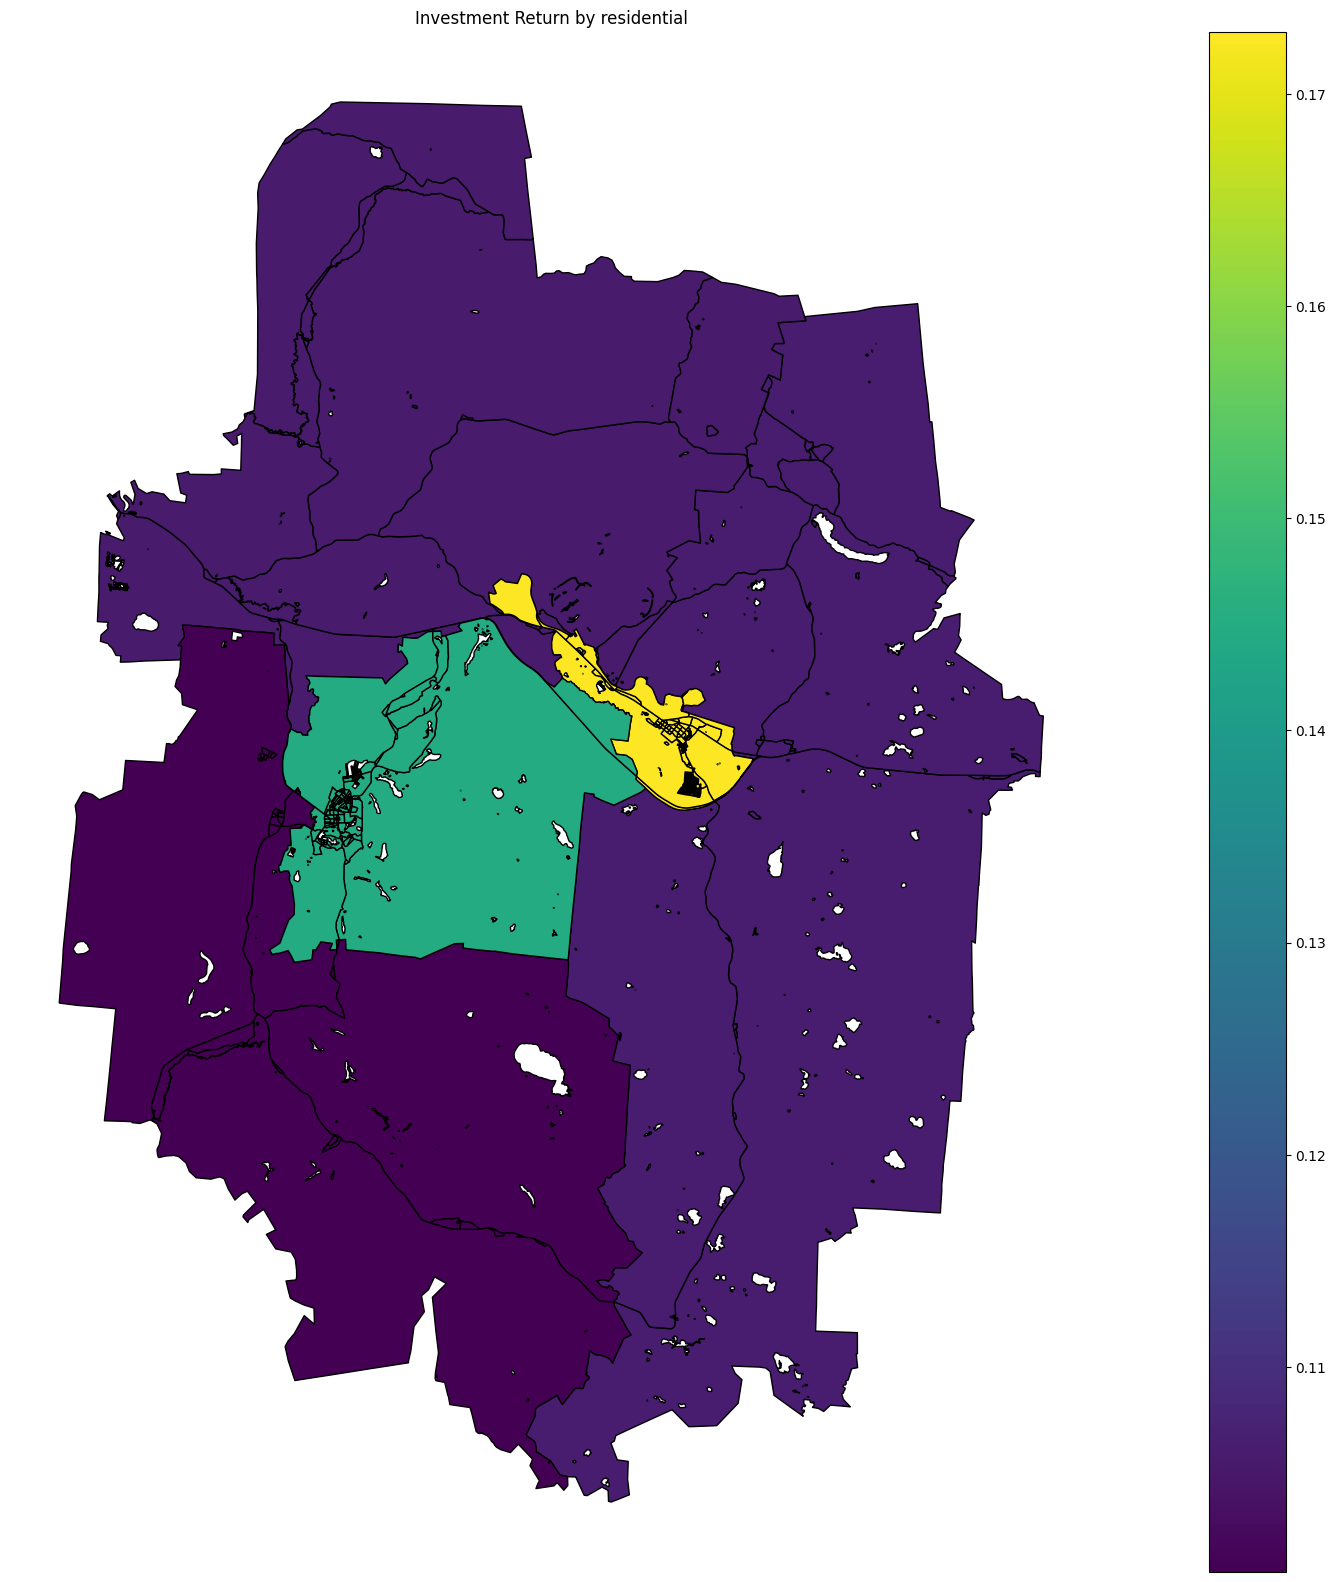

In [78]:

base_df.head(500).plot(column='InvestmentReturn',
         cmap='viridis',           # или 'OrRd', 'coolwarm', 'plasma', см. ниже для других вариантов
         legend=True,
         edgecolor='black',
         figsize=(30, 20))
plt.title('Investment Return by residential')  # или другая подходящая подпись
plt.axis('off')
plt.show()

In [80]:
features = {col: gdf[col] for col in gdf.columns if col != 'geometry'}
training_df = create_training_dataframe(gdf, features)
training_df.head()

,LandUseType,id,territory_id,name,Численность населения,Степень урбанизации территории,Средняя доступность до федеральных транспортных магистралей,Средняя доступность до центра региона,Связанность,Связанность населенных пунктов,...,Социальное обеспечение (базовое),Социальное обеспечение (базовое+),Социальное обеспечение (комфорт),Количество объектов инженерной инфраструктуры,"Количество электростанций (ТЭС, АЭС и пр.)",Количество больших водозаборов,Количество очистительных сооружений,Количество крупных водохранилищ,Количество газораспределительных станций,InvestmentReturn
0,residential,0,3.0,NaN,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,1.0,2.0,3.0,6.0,0.0,0.0,5.0,1.0,0.0,0.106077
1,recreation,0,3.0,NaN,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,1.0,2.0,3.0,6.0,0.0,0.0,5.0,1.0,0.0,0.060615
2,special,0,3.0,NaN,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,1.0,2.0,3.0,6.0,0.0,0.0,5.0,1.0,0.0,0.045461
3,industrial,0,3.0,NaN,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,1.0,2.0,3.0,6.0,0.0,0.0,5.0,1.0,0.0,0.181846
4,agriculture,0,3.0,NaN,2154.0,23.68,6.088,307.405291,4.004826,239.52,...,1.0,2.0,3.0,6.0,0.0,0.0,5.0,1.0,0.0,0.075769


In [20]:
# 3. Подготовка данных для модели
X_train, X_test, y_train, y_test, scaler, feature_columns = prepare_model_data(training_df)

# 4. Обучение модели
model = train_model(X_train, y_train)

# 5. Предсказание для новой территории
gdf_new = gdf.iloc[[0]]
predictions = predict_investment_attractiveness(gdf_new, model, scaler, feature_columns)
print("\nПредсказания для новой территории:\n", predictions)

# 6. Получение статистики
# Получение статистики
stats, base_stats, feature_importance = get_model_statistics(
    model, X_train, X_test, y_train, y_test, feature_columns, gdf_new, scaler
)


NameError: name 'prepare_model_data' is not defined

# Версия 2


In [3]:
URBAN_API = "https://urban-api.idu.kanootoko.org/api/v1"
import requests
id = 124

In [4]:
#211
#198
#124
#335
scenario_response = requests.get(
    f"{URBAN_API}/scenarios/{id}"
)
if scenario_response.status_code != 200:
    raise Exception("Ошибка при получении информации по сценарию")

scenario_data = scenario_response.json()
project_id = scenario_data.get("project", {}).get("project_id")
if project_id is None:
    raise Exception("Project ID is missing in scenario data.")

territory_response = requests.get(
    f"{URBAN_API}/projects/{project_id}/territory"
        )

if territory_response.status_code != 200:
            raise Exception("Ошибка при получении геометрии территории")
        
territory_data = territory_response.json()
territory_geometry = territory_data["geometry"]
territory_feature = {
    'type': 'Feature',
    'geometry': territory_geometry,
    'properties': {}
}
polygon_gdf = gpd.GeoDataFrame.from_features([territory_feature], crs=4326)
polygon_gdf = polygon_gdf.to_crs(32636)


scenario_indicators_response = requests.get(
    f"{URBAN_API}/scenarios/{id}/indicators_values"
)
if scenario_response.status_code != 200:
    raise Exception("Ошибка при получении информации по сценарию")

scenario_indicators = scenario_indicators_response.json()

indicator_attributes = {
    indicator['indicator']['name_full']: indicator['value']
    for indicator in scenario_indicators
}

# Добавляем эти значения как колонки в polygon_gdf
for name, value in indicator_attributes.items():
    polygon_gdf[name] = value
    
polygon_gdf

,geometry,Средняя этажность,Площадь территории,Численность населения,Плотность населения,Социальное обеспечение,Социальное обеспечение (базовое),Социальное обеспечение (базовое+),Социальное обеспечение (комфорт),Обеспечение инженерной инфраструктурой,...,Потенциал развития жилой застройки типа ИЖС,Потенциал развития малоэтажной жилой застройки,Потенциал развития среднеэтажной жилой застройки,Потенциал развития многоэтажной жилой застройки,Потенциал развития застройки общественно-деловой зоны,Потенциал развития застройки рекреационной зоны,Потенциал развития застройки зоны специального назначения,Потенциал развития застройки промышленной зоны,Потенциал развития застройки сельскохозяйственной зоны,Потенциал развития застройки транспортной зоны
0,"MULTIPOLYGON (((529877.02 6730827.593, 529893....",2.0,36595.0,0.0,0.0,4.2,2.7,0.9,0.6,5.0,...,3.0,2.0,2.0,1.0,2.0,4.0,3.0,3.0,2.0,4.0


In [11]:
project_id = 72
params = {
    "year": 2024,
    "source": "OSM"
}

territory_context_response = requests.get(
    f"{URBAN_API}/projects/{project_id}/context/functional_zones",
    params=params
)

if territory_context_response.status_code != 200:
    raise Exception("Ошибка при получении геометрии территории")

territory_data = territory_context_response.json()

# Проверяем, что структура — FeatureCollection
if "features" not in territory_data:
    raise Exception("Ожидалась структура FeatureCollection с ключом 'features'")

# Преобразуем все features в GeoDataFrame
polygon_context_gdf = gpd.GeoDataFrame.from_features(territory_data["features"], crs=4326)
polygon_context_gdf = polygon_context_gdf.to_crs(32636)

polygon_context_gdf


,geometry,functional_zone_id,territory,functional_zone_type,name,year,source,properties,created_at,updated_at
0,"MULTILINESTRING ((321251.598 6586893.964, 3212...",13702,"{'id': 1, 'name': 'Leningrad oblast'}","{'id': 14, 'name': 'unknown', 'nickname': 'unk...",None,2024,OSM,{},2024-11-29T15:07:18.098817Z,2024-11-29T15:07:18.098817Z
1,"MULTIPOLYGON (((329762.995 6583666.356, 329747...",15086,"{'id': 67, 'name': 'Гатчинский муниципальный р...","{'id': 14, 'name': 'unknown', 'nickname': 'unk...",None,2024,OSM,{},2024-12-01T17:49:03.818426Z,2024-12-01T17:49:03.818426Z
2,"POLYGON ((335568.363 6584915.953, 335568.559 6...",15072,"{'id': 2124, 'name': 'деревня Старосиверская'}","{'id': 4, 'name': 'industrial', 'nickname': 'П...",None,2024,OSM,{'landuse_zon': 'Industrial'},2024-12-01T17:49:02.360089Z,2024-12-01T17:49:02.360089Z
3,"POLYGON ((334732.201 6585463, 334792.603 65853...",15230,"{'id': 2124, 'name': 'деревня Старосиверская'}","{'id': 7, 'name': 'business', 'nickname': 'Общ...",None,2024,OSM,{'landuse_zon': 'Business'},2024-12-01T17:49:17.530799Z,2024-12-01T17:49:17.530799Z
4,"POLYGON ((338747.147 6580055.547, 338703.328 6...",15194,"{'id': 82, 'name': 'Сиверское городское поселе...","{'id': 1, 'name': 'residential', 'nickname': '...",None,2024,OSM,{'landuse_zon': 'Residential'},2024-12-01T17:49:14.414830Z,2024-12-01T17:49:14.414830Z
...,...,...,...,...,...,...,...,...,...,...
1304,"MULTIPOLYGON (((330868.533 6582135.168, 330876...",110673,"{'id': 2230, 'name': 'деревня Межно'}","{'id': 2, 'name': 'recreation', 'nickname': 'Р...",None,2024,OSM,{'landuse_zon': 'Recreation'},2024-12-11T14:22:07.328299Z,2024-12-11T14:22:07.328299Z
1305,"POLYGON ((329915.602 6569460.846, 329904.035 6...",123885,"{'id': 1, 'name': 'Leningrad oblast'}","{'id': 14, 'name': 'unknown', 'nickname': 'unk...",None,2024,OSM,{},2024-12-17T16:22:38.444659Z,2024-12-17T16:22:38.444659Z
1306,"POLYGON ((321249.514 6570566.852, 321259.932 6...",123982,"{'id': 1, 'name': 'Leningrad oblast'}","{'id': 2, 'name': 'recreation', 'nickname': 'Р...",None,2024,OSM,{'landuse_zon': 'Recreation'},2024-12-17T16:31:55.771201Z,2024-12-17T16:31:55.771201Z
1307,"MULTILINESTRING ((322841.531 6571307.529, 3228...",124034,"{'id': 1, 'name': 'Leningrad oblast'}","{'id': 2, 'name': 'recreation', 'nickname': 'Р...",None,2024,OSM,{'landuse_zon': 'Recreation'},2024-12-17T16:37:10.453153Z,2024-12-17T16:37:10.453153Z


In [ ]:
# polygon_context_gdf.explore()

In [ ]:
# for col in polygon_gdf.columns:
#     unique_vals = polygon_gdf[col].unique()
#     print(f"Атрибут: {col}")
#     print(f"Значения: {unique_vals}\n")


In [5]:
# Выводим имена столбцов, где хотя бы одно значение попадает в диапазон от -5 до 5, исключая 0
attributes_in_range = [
    col for col in polygon_gdf.columns
    if polygon_gdf[col].dtype.kind in 'if'  # Только числовые столбцы (int, float)
    and (((polygon_gdf[col] >= -5) & (polygon_gdf[col] <= 5) & (polygon_gdf[col] != 0)).any())
]

print(attributes_in_range)



['Средняя этажность', 'Социальное обеспечение', 'Социальное обеспечение (базовое)', 'Социальное обеспечение (базовое+)', 'Социальное обеспечение (комфорт)', 'Обеспечение инженерной инфраструктурой', 'Население', 'Оценка по экологическому каркасу', 'Экологическая ситуация', 'Потенциал размещения бизнес-кластера', 'Потенциал размещения промышленной зоны', 'Потенциал размещения логистического, складского комплекса', 'Потенциал размещения порта', 'Оценка по каркасу расселения', 'Оценка по транспортному каркасу', 'Транспортное обеспечение', 'Средняя доступность до федеральных транспортных магистралей', 'Количество автозаправочных станций', 'Количество аэропортов местного значения', 'Количество остановок железнодорожного транспорта', 'Плотность улично-дорожной сети', 'Потенциал развития жилой застройки типа ИЖС', 'Потенциал развития малоэтажной жилой застройки', 'Потенциал развития среднеэтажной жилой застройки', 'Потенциал развития многоэтажной жилой застройки', 'Потенциал развития застройк

In [6]:
for col in attributes_in_range:
    unique_vals = polygon_gdf[col].unique()
    print(f"Атрибут: {col}")
    print(f"Значения: {unique_vals}\n")


Атрибут: Средняя этажность
Значения: [2.]

Атрибут: Социальное обеспечение
Значения: [4.2]

Атрибут: Социальное обеспечение (базовое)
Значения: [2.7]

Атрибут: Социальное обеспечение (базовое+)
Значения: [0.9]

Атрибут: Социальное обеспечение (комфорт)
Значения: [0.6]

Атрибут: Обеспечение инженерной инфраструктурой
Значения: [5.]

Атрибут: Население
Значения: [4.]

Атрибут: Оценка по экологическому каркасу
Значения: [2.]

Атрибут: Экологическая ситуация
Значения: [-3.33]

Атрибут: Потенциал размещения бизнес-кластера
Значения: [-1.]

Атрибут: Потенциал размещения промышленной зоны
Значения: [-0.01]

Атрибут: Потенциал размещения логистического, складского комплекса
Значения: [-0.01]

Атрибут: Потенциал размещения порта
Значения: [1.05]

Атрибут: Оценка по каркасу расселения
Значения: [5.]

Атрибут: Оценка по транспортному каркасу
Значения: [5.]

Атрибут: Транспортное обеспечение
Значения: [1.8]

Атрибут: Средняя доступность до федеральных транспортных магистралей
Значения: [3.863]

Ат

/var/folders/h8/0wmx2zx90bn60jw8zc1r4qjc0000gn/T/ipykernel_4744/3801394392.py:180: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


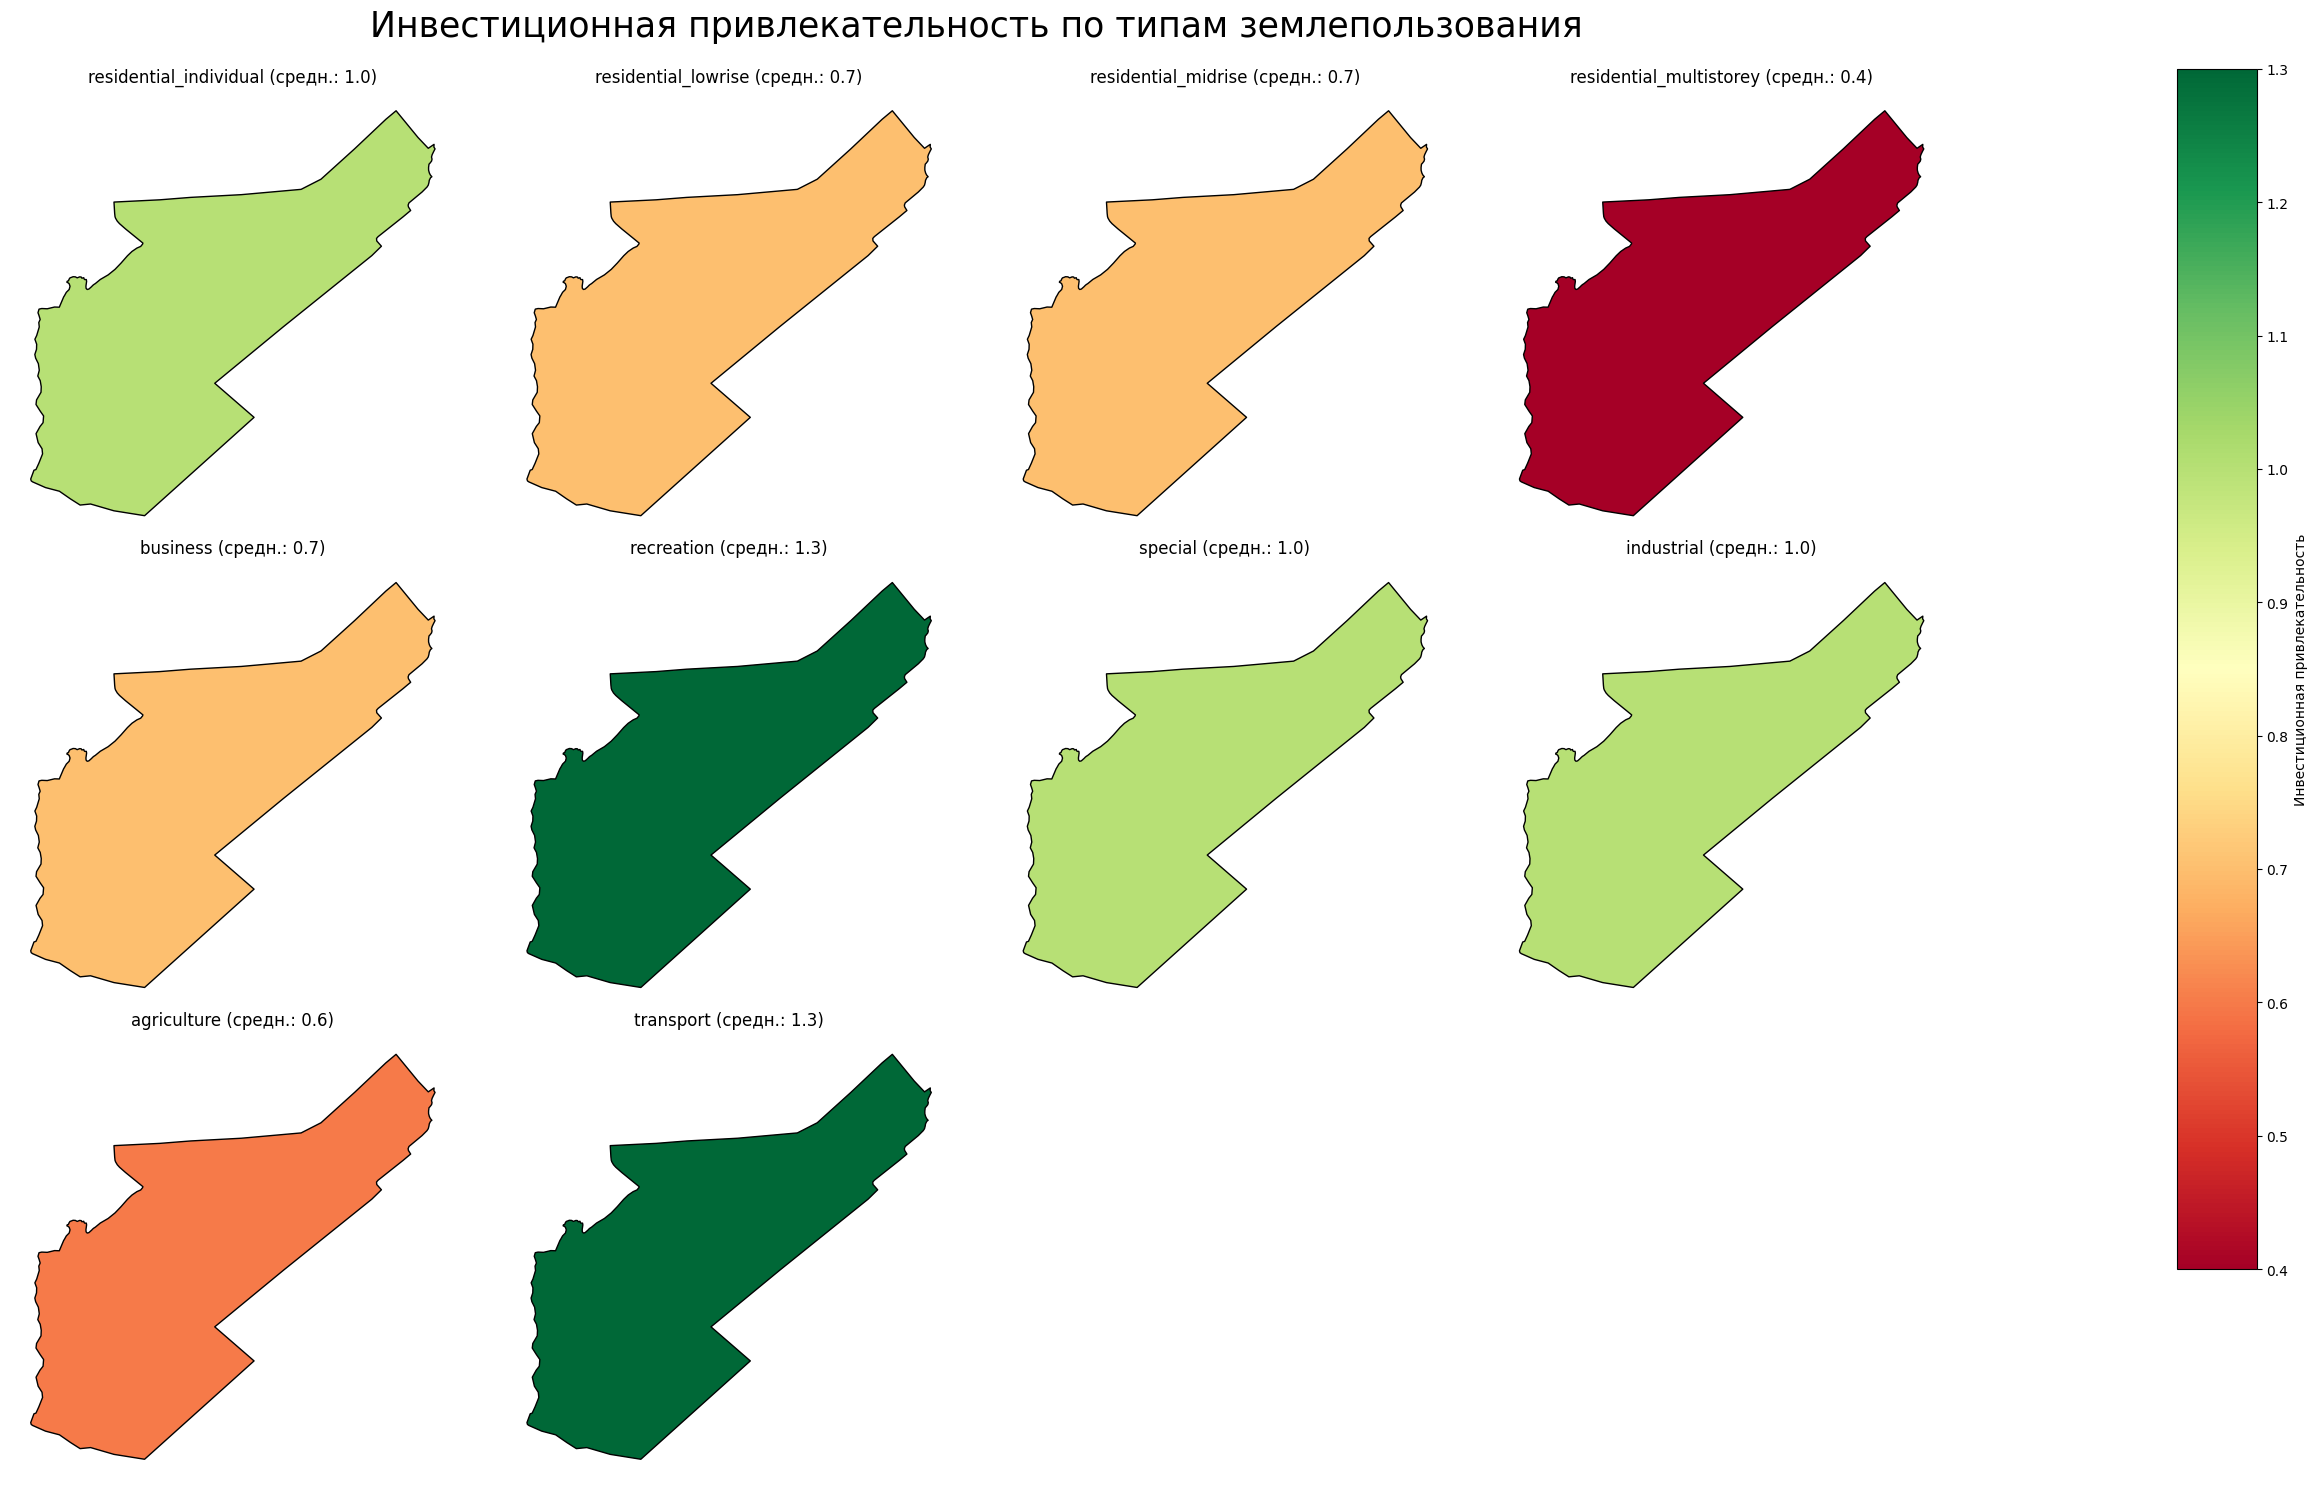

In [13]:
import matplotlib.pyplot as plt
import math
import pandas as pd

# Карта соответствия land use → колонка с потенциалом
land_use_to_potential_column = {
    'residential_individual': 'Потенциал развития жилой застройки типа ИЖС',
    'residential_lowrise': 'Потенциал развития малоэтажной жилой застройки',
    'residential_midrise': 'Потенциал развития среднеэтажной жилой застройки',
    'residential_multistorey': 'Потенциал развития многоэтажной жилой застройки',
    'business': 'Потенциал развития застройки общественно-деловой зоны',
    'recreation': 'Потенциал развития застройки рекреационной зоны',
    'special': 'Потенциал развития застройки зоны специального назначения',
    'industrial': 'Потенциал развития застройки промышленной зоны',
    'agriculture': 'Потенциал развития застройки сельскохозяйственной зоны',
    'transport': 'Потенциал развития застройки транспортной зоны'
}

weights = {
    'residential_individual': {
        'Население': 1.3,  # Умеренная плотность важна для ИЖС
        'Социальное обеспечение': 1.4,  # Инфраструктура критична для жизни
        'Экологическая ситуация': 1.5,  # Чистая среда важна для частных домов
        'Средняя доступность до близлежащего крупного населенного пункта': 1.2,  # Близость к городу
        'Транспортное обеспечение': 1.1,  # Удобство поездок
        'default': 1.0
    },
    'residential_lowrise': {
        'Население': 1.4,  # Нужна достаточная плотность для малоэтажки
        'Социальное обеспечение': 1.3,  # Инфраструктура важна
        'Экологическая ситуация': 1.4,  # Комфортная среда
        'Транспортное обеспечение': 1.2,  # Доступность
        'default': 1.0
    },
    'residential_midrise': {
        'Средняя этажность': 1.5,  # Соответствие существующей застройке
        'Население': 1.4,  # Плотность для среднеэтажных домов
        'Социальное обеспечение': 1.3,  # Услуги для жителей
        'Транспортное обеспечение': 1.2,  # Связь с городом
        'default': 1.0
    },
    'residential_multistorey': {
        'Средняя этажность': 1.5,  # Подходит для высотной застройки
        'Население': 1.4,  # Высокая плотность для многоэтажек
        'Транспортное обеспечение': 1.3,  # Критично для больших жилых зон
        'Социальное обеспечение': 1.2,  # Базовые услуги
        'default': 1.0
    },
    'business': {
        'Транспортное обеспечение': 1.5,  # Доступность для клиентов и сотрудников
        'Население': 1.4,  # Потребительская база
        'Социальное обеспечение (комфорт)': 1.3,  # Привлекательность для бизнеса
        'Средняя доступность до близлежащего крупного населенного пункта': 1.2,  # Близость к рынкам
        'default': 1.0
    },
    'recreation': {
        'Экологическая ситуация': 1.5,  # Чистая природа — ключевой фактор
        'Социальное обеспечение (комфорт)': 1.4,  # Удобства для отдыха
        'Транспортное обеспечение': 1.2,  # Доступность для посетителей
        'Население': 0.8,  # Высокая плотность может мешать
        'default': 1.0
    },
    'special': {
        'Потенциал размещения порта': 1.5,  # Основной фактор для спецзон
        'Транспортное обеспечение': 1.4,  # Логистика важна
        'Потенциал размещения логистического, складского комплекса': 1.3,  # Дополнительная поддержка
        'default': 1.0
    },
    'industrial': {
        'Потенциал размещения логистического, складского комплекса': 1.5,  # Ключевая инфраструктура
        'Транспортное обеспечение': 1.4,  # Доставка сырья и продукции
        'Экологическая ситуация': 0.8,  # Промзоны менее требовательны к экологии
        'Население': 0.9,  # Высокая плотность может быть помехой
        'default': 1.0
    },
    'agriculture': {
        'Экологическая ситуация': 1.5,  # Качество среды для сельского хозяйства
        'Население': 0.8,  # Высокая плотность снижает доступность земли
        'Транспортное обеспечение': 1.2,  # Доставка продукции
        'Средняя доступность до близлежащего крупного населенного пункта': 1.1,  # Рынки сбыта
        'default': 1.0
    },
    'transport': {
        'Потенциал размещения логистического, складского комплекса': 1.5,  # Логистика критична
        'Количество аэропортов местного значения': 1.4,  # Поддержка авиации
        'Средняя доступность до близлежащего крупного населенного пункта': 1.3,  # Связь с центрами
        'default': 1.0
    }
}

def plot_attribute_weights(weights_dict, land_use_key, ax):
    weights_for_lu = weights_dict[land_use_key].copy()
    weights_for_lu.pop('default', None)
    
    # Разделение на сильные (>1) и слабые (<1) стороны
    strong = {k: v for k, v in weights_for_lu.items() if v > 1}
    weak = {k: v for k, v in weights_for_lu.items() if v < 1}

    # Объединение для единой сортировки
    all_weights = {**strong, **weak}
    sorted_items = sorted(all_weights.items(), key=lambda x: x[1], reverse=True)

    labels, values = zip(*sorted_items)
    colors = ['green' if v > 1 else 'red' for v in values]

    ax.barh(labels, values, color=colors)
    ax.set_xlim(0, max(values) + 0.5)
    ax.set_title(f'Влияние факторов: {land_use_key}', fontsize=10)
    ax.invert_yaxis()  # чтобы важные сверху


# Исключаем потенциалы из расчёта
potential_cols = list(land_use_to_potential_column.values())

# Только числовые столбцы без потенциалов, в пределах от -5 до 5, и не равные 0
attributes_in_range = [
    col for col in polygon_gdf.columns
    if polygon_gdf[col].dtype.kind in 'if'
    and col not in potential_cols
    and (((polygon_gdf[col] >= -5) & (polygon_gdf[col] <= 5) & (polygon_gdf[col] != 0)).any())
]

# Вычисление инвестиционной привлекательности с учётом весов
for land_use, potential_col in land_use_to_potential_column.items():
    polygon_gdf[f'ИП_{land_use}'] = polygon_gdf.apply(
        lambda row: round(
            (
                sum([row[attr] * weights[land_use].get(attr, weights[land_use]['default']) 
                     for attr in attributes_in_range if pd.notna(row[attr])]) /
                len([row[attr] for attr in attributes_in_range if pd.notna(row[attr])])
            ) * (row[potential_col] / 5), 1
        ) if pd.notna(row[potential_col]) else None,
        axis=1
    )

# Список столбцов с результатами
score_cols = [f'ИП_{lu}' for lu in land_use_to_potential_column]

# Границы цвета
vmin = polygon_gdf[score_cols].min().min()
vmax = polygon_gdf[score_cols].max().max()

# Сетка графиков
n = len(land_use_to_potential_column)
cols = 4
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
axes = axes.flatten()

# Отрисовка каждой карты
for i, (land_use, ax) in enumerate(zip(land_use_to_potential_column.keys(), axes)):
    col = f'ИП_{land_use}'
    mean_val = polygon_gdf[col].mean()

    polygon_gdf.plot(
        column=col,
        cmap='RdYlGn',
        legend=False,
        ax=ax,
        edgecolor='black',
        vmin=vmin,
        vmax=vmax
    )
    ax.set_title(f"{land_use} (средн.: {mean_val:.1f})", fontsize=12)
    ax.axis('off')

# Удаление пустых осей
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# Общая цветовая шкала
fig.subplots_adjust(right=0.88)
cax = fig.add_axes([1.1, 0.15, 0.04, 0.8])
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []
fig.colorbar(sm, cax=cax, label='Инвестиционная привлекательность')

plt.suptitle("Инвестиционная привлекательность по типам землепользования", fontsize=25, y=0.99)
plt.tight_layout()
plt.show()

/var/folders/h8/0wmx2zx90bn60jw8zc1r4qjc0000gn/T/ipykernel_4744/270139048.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig1.tight_layout()


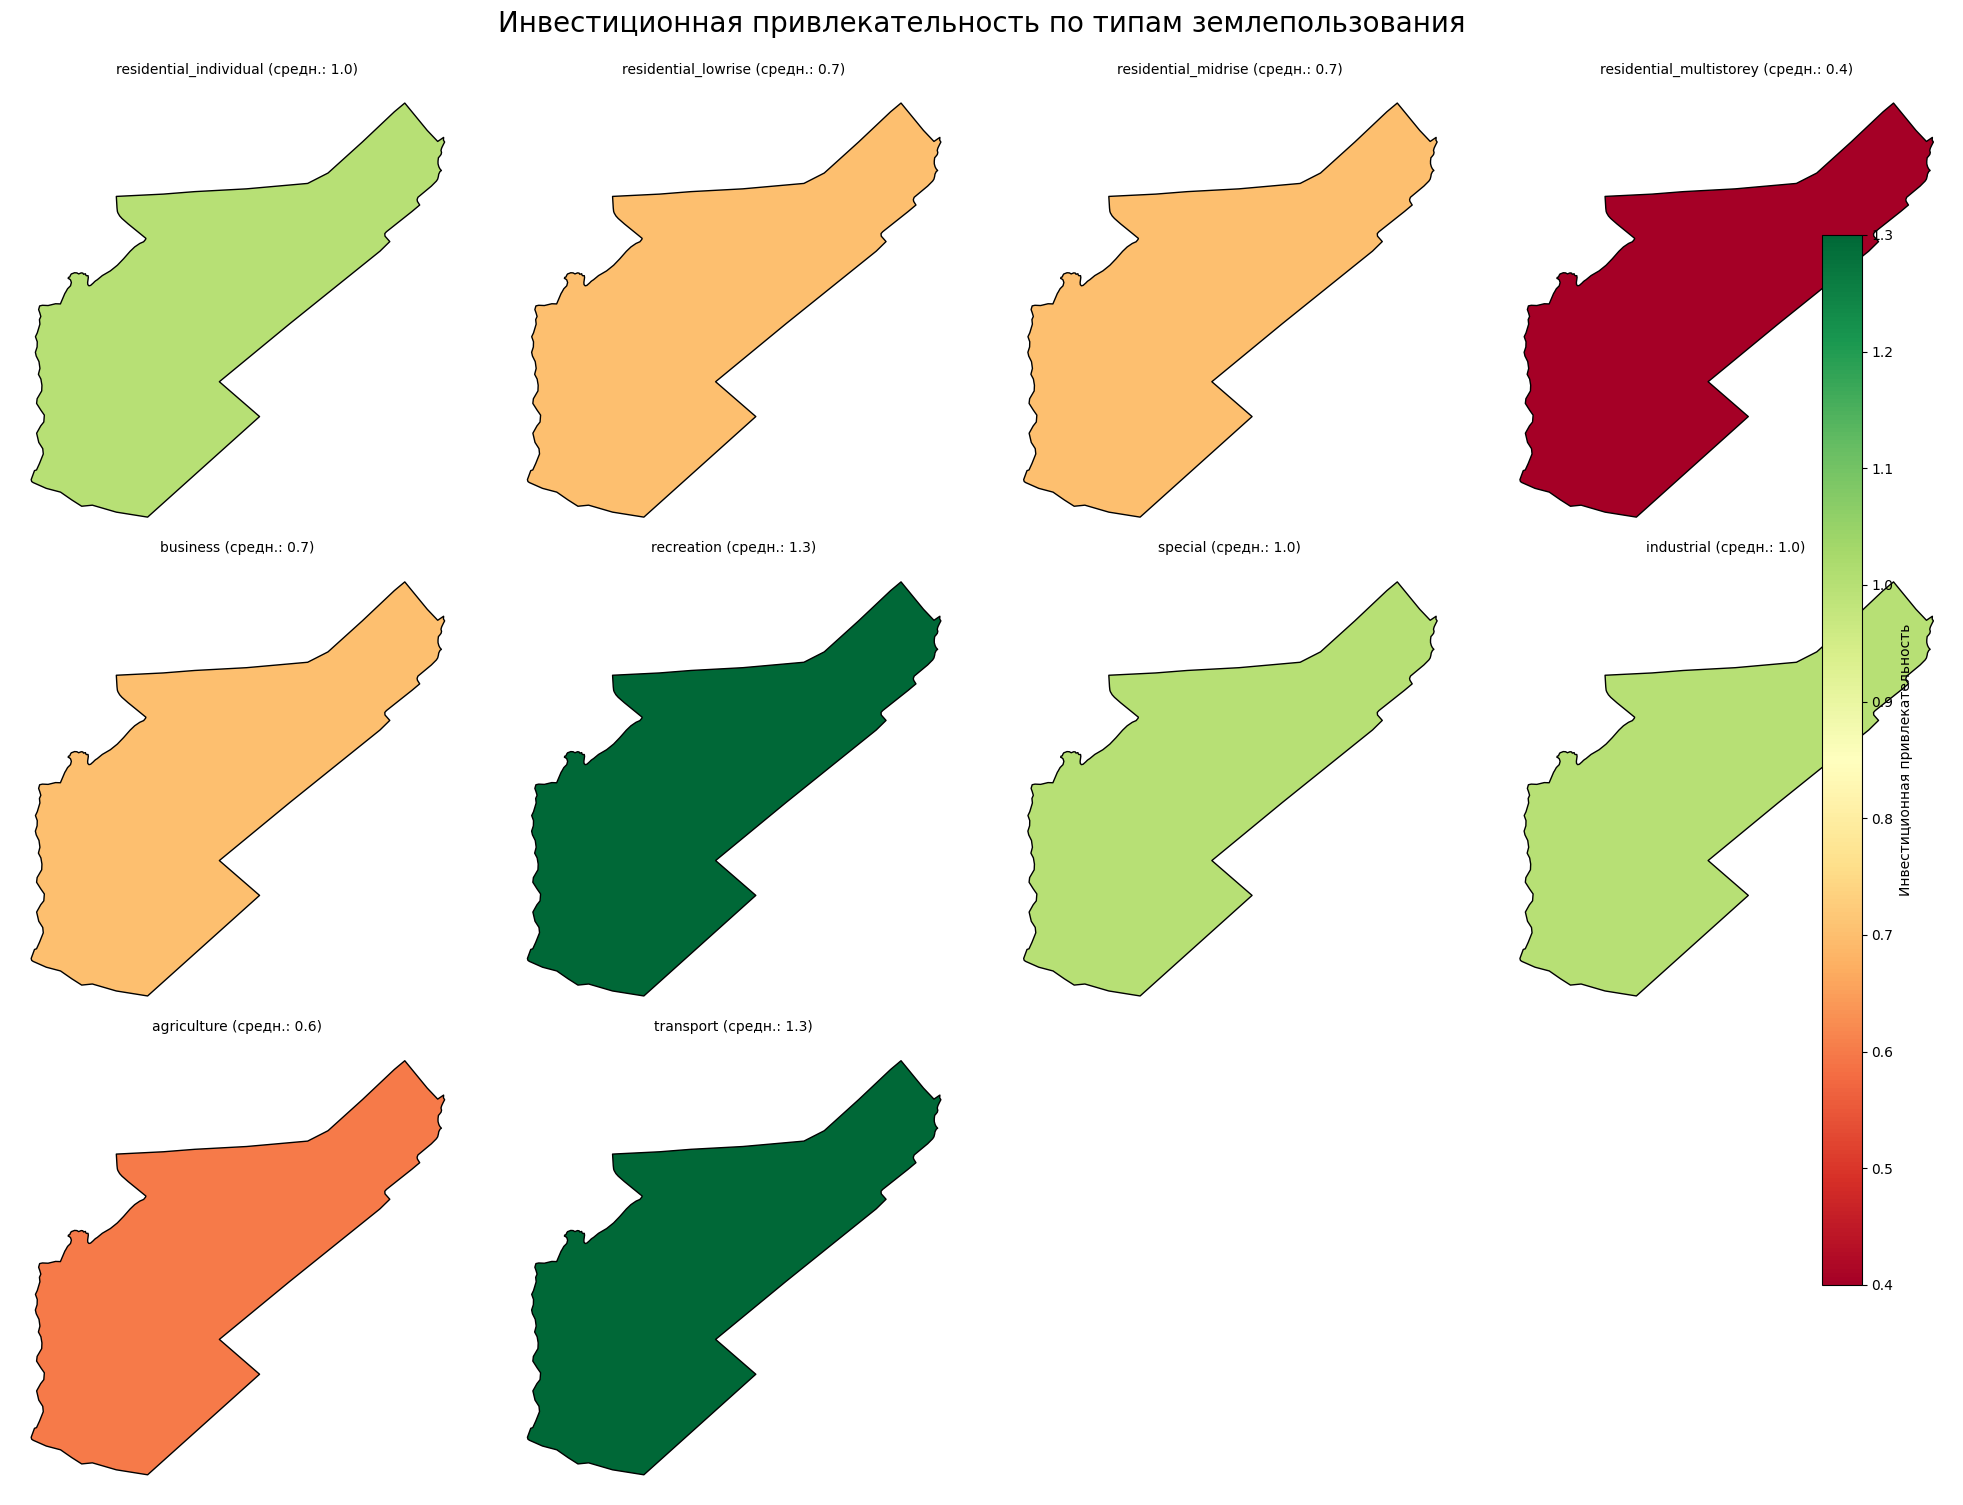

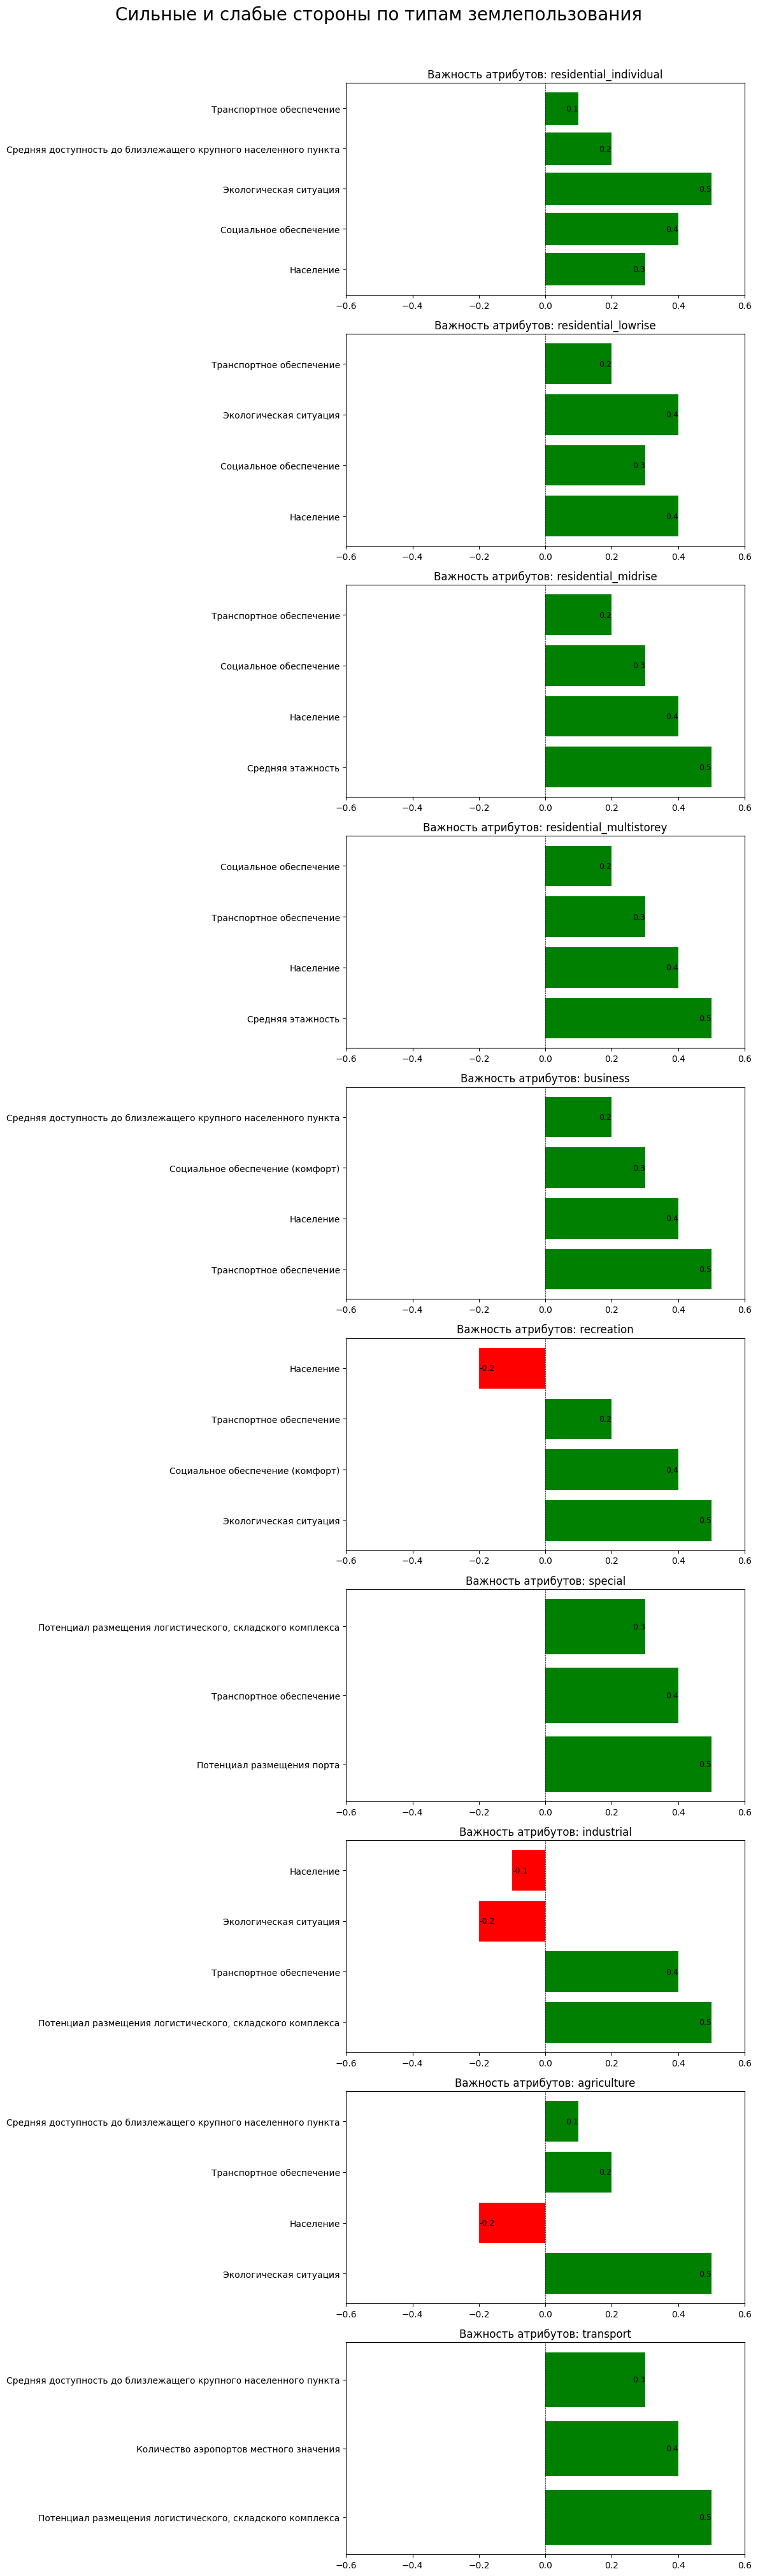

In [14]:
import matplotlib.pyplot as plt
import math
import pandas as pd
import numpy as np

# [Предыдущие словари land_use_to_potential_column и weights остаются без изменений]

# Исключаем потенциалы из расчёта
potential_cols = list(land_use_to_potential_column.values())

# Только числовые столбцы без потенциалов, в пределах от -5 до 5, и не равные 0
attributes_in_range = [
    col for col in polygon_gdf.columns
    if polygon_gdf[col].dtype.kind in 'if'
    and col not in potential_cols
    and (((polygon_gdf[col] >= -5) & (polygon_gdf[col] <= 5) & (polygon_gdf[col] != 0)).any())
]

# Вычисление инвестиционной привлекательности с учётом весов
for land_use, potential_col in land_use_to_potential_column.items():
    polygon_gdf[f'ИП_{land_use}'] = polygon_gdf.apply(
        lambda row: round(
            (
                sum([row[attr] * weights[land_use].get(attr, weights[land_use]['default']) 
                     for attr in attributes_in_range if pd.notna(row[attr])]) /
                len([row[attr] for attr in attributes_in_range if pd.notna(row[attr])])
            ) * (row[potential_col] / 5), 1
        ) if pd.notna(row[potential_col]) else None,
        axis=1
    )

# Список столбцов с результатами
score_cols = [f'ИП_{lu}' for lu in land_use_to_potential_column]

# Границы цвета
vmin = polygon_gdf[score_cols].min().min()
vmax = polygon_gdf[score_cols].max().max()

# Первая фигура: Карты инвестиционной привлекательности
n = len(land_use_to_potential_column)
cols = 4
rows = math.ceil(n / cols)

fig1 = plt.figure(figsize=(5 * cols, 5 * rows))
for i, land_use in enumerate(land_use_to_potential_column.keys()):
    ax = fig1.add_subplot(rows, cols, i + 1)
    col = f'ИП_{land_use}'
    mean_val = polygon_gdf[col].mean()

    polygon_gdf.plot(
        column=col,
        cmap='RdYlGn',
        legend=False,
        ax=ax,
        edgecolor='black',
        vmin=vmin,
        vmax=vmax
    )
    ax.set_title(f"{land_use} (средн.: {mean_val:.1f})", fontsize=10)
    ax.axis('off')

# Цветовая шкала для первой фигуры
fig1.subplots_adjust(right=0.88)
cax = fig1.add_axes([0.92, 0.15, 0.02, 0.7])
sm = plt.cm.ScalarMappable(cmap='RdYlGn', norm=plt.Normalize(vmin=vmin, vmax=vmax))
sm._A = []
fig1.colorbar(sm, cax=cax, label='Инвестиционная привлекательность')

plt.suptitle("Инвестиционная привлекательность по типам землепользования", 
             fontsize=20, y=1.0)
fig1.tight_layout()

# Вторая фигура: Сильные и слабые стороны (вертикально)
fig2 = plt.figure(figsize=(12, 4 * n))  # Ширина фиксирована, высота зависит от количества типов

for i, land_use in enumerate(land_use_to_potential_column.keys()):
    ax = fig2.add_subplot(n, 1, i + 1)
    
    # Получаем веса для текущего типа землепользования
    current_weights = weights[land_use]
    attrs = [k for k in current_weights.keys() if k != 'default']
    values = [current_weights[k] - 1.0 for k in attrs]  # Отнимаем 1.0 для отклонения от базового
    
    # Разделяем положительные и отрицательные значения
    colors = ['green' if v >= 0 else 'red' for v in values]
    
    # Создаем горизонтальную столбчатую диаграмму
    bars = ax.barh(attrs, values, color=colors)
    ax.axvline(x=0, color='black', linestyle='--', linewidth=0.5)
    
    # Настройка графика
    ax.set_title(f"Важность атрибутов: {land_use}", fontsize=12)
    ax.set_xlim(-0.6, 0.6)
    ax.tick_params(axis='y', labelsize=10)
    
    # Добавляем подписи значений
    for bar in bars:
        width = bar.get_width()
        ax.text(
            width, bar.get_y() + bar.get_height()/2,
            f'{width:.1f}',
            ha='left' if width < 0 else 'right',
            va='center',
            fontsize=9
        )

plt.suptitle("Сильные и слабые стороны по типам землепользования", 
             fontsize=20, y=1.01)
fig2.tight_layout()

# Показываем обе фигуры
plt.show()